In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 192kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.18MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.25MB/s]


In [ ]:
class VAE(nn.Module):

    def __init__(self):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, 20)
        self.fc_logvar = nn.Linear(400, 20)

        # Decoder
        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [ ]:
def loss_function(recon_x, x, mu, logvar):

    BCE = nn.functional.binary_cross_entropy(
        recon_x, x, reduction='sum'
    )

    KLD = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return BCE + KLD

In [ ]:
model = VAE()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):

    for data, _ in train_loader:

        data = data.view(-1, 784)

        recon, mu, logvar = model(data)

        loss = loss_function(recon, data, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:", epoch+1, "Loss:", loss.item())

Epoch: 1 Loss: 25289.78125
Epoch: 2 Loss: 24109.501953125
Epoch: 3 Loss: 22360.470703125
Epoch: 4 Loss: 23552.3125
Epoch: 5 Loss: 23717.9453125


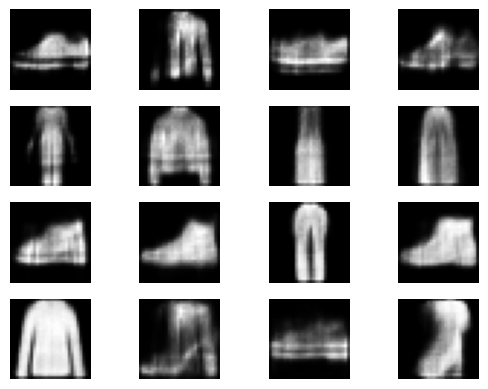

In [ ]:
with torch.no_grad():

    z = torch.randn(16, 20)

    samples = model.decode(z).view(-1, 28, 28)

for i in range(16):

    plt.subplot(4,4,i+1)
    plt.imshow(samples[i], cmap='gray')
    plt.axis('off')

plt.show()